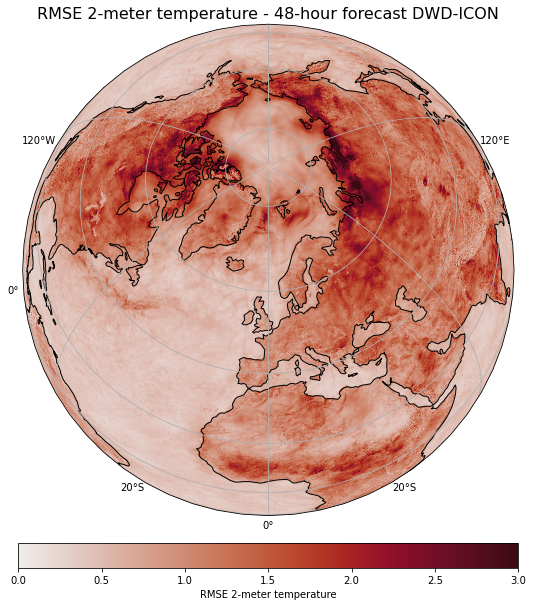

In [10]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import cmocean
# Load the NetCDF file
mpath = "/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/DWD-ICON/"
file_path = mpath+"48h_rmse.DWD-ICON_202404.nc"
data = xr.open_dataset(file_path)

# Extract variables
ci = data['2t'][0, 0, :, :]  # First time step
lon = data['lon'][:]
lat = data['lat'][:]

# Add a cyclic point to avoid gaps in the plot
ci_cyclic, lon_cyclic = add_cyclic_point(ci, coord=lon)

# Create a figure and specify the projection
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.Orthographic(central_longitude=0, central_latitude=65))

# Plot the data
c = ax.pcolormesh(
    lon_cyclic, lat, ci_cyclic, transform=ccrs.PlateCarree(), cmap=cmocean.cm.amp, vmin=0, vmax=3
)
ax.coastlines(resolution='110m', color='black', linewidth=1)

# Add gridlines
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

# Add a colorbar
cb = plt.colorbar(c, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046)
cb.set_label("RMSE 2-meter temperature")

# Set the title
plt.title("RMSE 2-meter temperature - 48-hour forecast DWD-ICON", fontsize=16)

# Show the plot
plt.show()


In [3]:
data

<xarray.Dataset>
Dimensions:    (time: 1, bnds: 2, lon: 2879, lat: 1441, height: 1)
Coordinates:
  * time       (time) datetime64[ns] 2024-04-18T12:00:00
  * lon        (lon) float64 -180.0 -179.9 -179.8 -179.6 ... 179.5 179.6 179.8
  * lat        (lat) float64 -90.0 -89.88 -89.75 -89.62 ... 89.75 89.88 90.0
  * height     (height) float64 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] ...
    ci         (time, lat, lon) float32 ...
    2t         (time, height, lat, lon) float32 ...
Attributes:
    CDI:          Climate Data Interface version 2.0.5 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Deutscher Wetterdienst
    history:      Thu Oct 31 12:24:15 2024: cdo merge sqrt.timmean.sqr.sub.FR...
    CDO:          Climate Data Operators version 2.0.5 (https://mpimet.mpg.de...